In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve

In [2]:
#Data Specs
data = pd.read_csv("../../data/marketdata.csv")
print(len(data))

minority_class = (data['market_crisis']>0).sum()
majority_class = (data['market_crisis']==0).sum()
imbalance = minority_class/len(data)
print(minority_class)
print(majority_class)
print(imbalance)
print(data.columns.tolist())

4701
434
4267
0.09232078281216763
['Date', 'SPY_roll_10', 'SPY_roll_20', 'SPY_roll_60', 'SPY_day_return', 'SPY_5_day_return', 'SPY_20_day_return', 'QQQ_day_return', 'IWM_day_return', 'TLT_day_return', 'GLD_day_return', 'SPY_drawdown', 'QQQ_drawdown', 'IWM_drawdown', 'SPY_TLT_corr_20', 'SPY_TLT_corr_60', 'SPY_GLD_corr_20', 'SPY_vol_ratio', 'QQQ_vol_ratio', 'IWM_vol_ratio', 'spy_above_avg', 'market_crisis']


In [3]:
#Train Test Split
X = data[['SPY_roll_10', 'SPY_roll_20', 'SPY_roll_60', 'SPY_day_return', 'SPY_5_day_return', 'SPY_20_day_return', 'QQQ_day_return', 'IWM_day_return', 'TLT_day_return', 'GLD_day_return', 'SPY_drawdown', 'QQQ_drawdown', 'IWM_drawdown', 'SPY_TLT_corr_20', 'SPY_TLT_corr_60', 'SPY_GLD_corr_20', 'SPY_vol_ratio', 'QQQ_vol_ratio', 'IWM_vol_ratio', 'spy_above_avg']]
y = data['market_crisis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

print(len(X_train), len(X_test))

3760 941


In [4]:
#Scale Data
scale = StandardScaler()
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

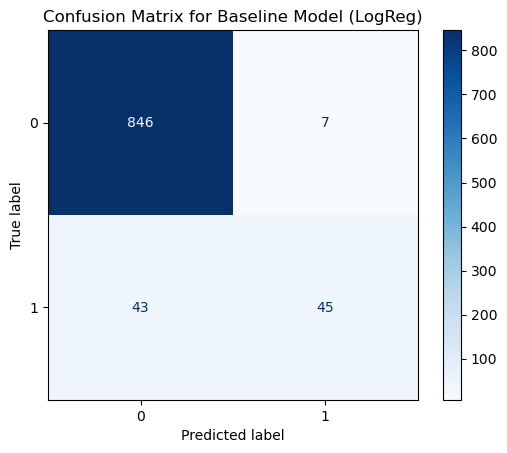

Train Acc:0.9462765957446808
Test Acc:0.946865037194474
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       853
           1       0.87      0.51      0.64        88

    accuracy                           0.95       941
   macro avg       0.91      0.75      0.81       941
weighted avg       0.94      0.95      0.94       941



In [5]:
baseline_model = LogisticRegression()

baseline_model.fit(X_train_scaled, y_train)

base_train_acc = baseline_model.score(X_train_scaled, y_train)
base_test_acc = baseline_model.score(X_test_scaled, y_test)
base_pred = baseline_model.predict(X_test_scaled)

base_conf = confusion_matrix(y_test, base_pred)
conf_plot = ConfusionMatrixDisplay(confusion_matrix=base_conf)
conf_plot.plot(cmap="Blues")
plt.title("Confusion Matrix for Baseline Model (LogReg)")
plt.savefig("../visualizations/LR_ML/baseline_matrix_LR.png")
plt.show()

print(f"Train Acc:{base_train_acc}")
print(f"Test Acc:{base_test_acc}")
print(classification_report(y_test, base_pred))

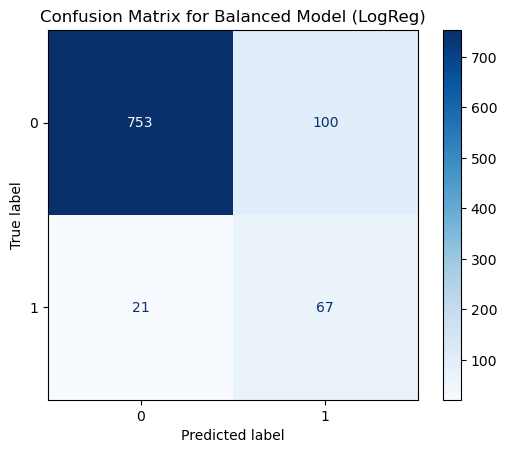

Train Acc:0.8582446808510639
Test Acc:0.871413390010627
              precision    recall  f1-score   support

           0       0.97      0.88      0.93       853
           1       0.40      0.76      0.53        88

    accuracy                           0.87       941
   macro avg       0.69      0.82      0.73       941
weighted avg       0.92      0.87      0.89       941



In [6]:
#Balanced Model
balanced_model = LogisticRegression(class_weight="balanced")

balanced_model.fit(X_train_scaled, y_train)

bal_train_acc = balanced_model.score(X_train_scaled, y_train)
bal_test_acc = balanced_model.score(X_test_scaled, y_test)
bal_pred = balanced_model.predict(X_test_scaled)

bal_conf = confusion_matrix(y_test, bal_pred)
conf_plot = ConfusionMatrixDisplay(confusion_matrix=bal_conf)
conf_plot.plot(cmap="Blues")
plt.title("Confusion Matrix for Balanced Model (LogReg)")
plt.savefig("../visualizations/LR_ML/balanced_matrix_LR.png")
plt.show()

print(f"Train Acc:{bal_train_acc}")
print(f"Test Acc:{bal_test_acc}")
print(classification_report(y_test, bal_pred))

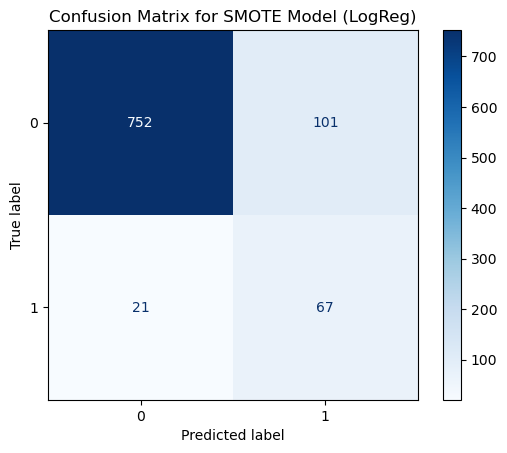

Train Acc:0.841095489162273
Test Acc:0.8703506907545164
              precision    recall  f1-score   support

           0       0.97      0.88      0.92       853
           1       0.40      0.76      0.52        88

    accuracy                           0.87       941
   macro avg       0.69      0.82      0.72       941
weighted avg       0.92      0.87      0.89       941



In [7]:
#SMOTE with Logistic Regression

X_sm, y_sm = SMOTE(random_state=101).fit_resample(X_train_scaled, y_train)
sm = LogisticRegression(max_iter=1000, random_state=101)
sm.fit(X_sm, y_sm)

sm_train_acc = sm.score(X_sm, y_sm)
sm_test_acc = sm.score(X_test_scaled, y_test)
sm_pred = sm.predict(X_test_scaled)

sm_conf = confusion_matrix(y_test, sm_pred)
conf_plot = ConfusionMatrixDisplay(confusion_matrix=sm_conf)
conf_plot.plot(cmap="Blues")
plt.title("Confusion Matrix for SMOTE Model (LogReg)")
plt.savefig("../visualizations/LR_ML/SMOTE_matrix_LR.png")
plt.show()

print(f"Train Acc:{sm_train_acc}")
print(f"Test Acc:{sm_test_acc}")
print(classification_report(y_test, sm_pred))

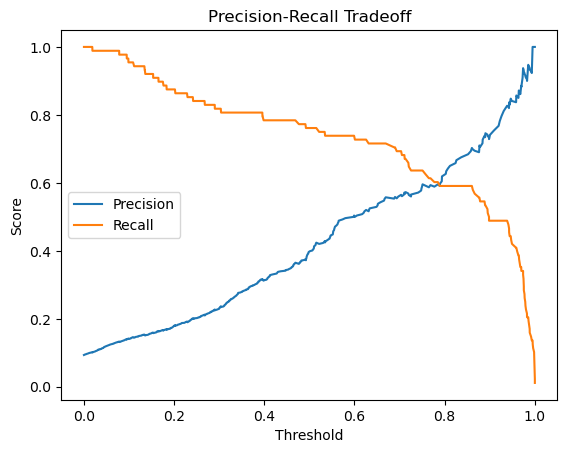

              precision    recall  f1-score   support

  Normal (0)       0.96      0.96      0.96       853
  Crisis (1)       0.63      0.59      0.61        88

    accuracy                           0.93       941
   macro avg       0.79      0.78      0.78       941
weighted avg       0.93      0.93      0.93       941



In [8]:
#Adjusting Treshold

y_prob = sm.predict_proba(X_test_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
plt.figure()
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff')
plt.legend()
plt.show()


y_pred_adjusted = (y_prob >= 0.80).astype(int)
print(classification_report(y_test, y_pred_adjusted, target_names=["Normal (0)", "Crisis (1)"]))


In [9]:
#Grid Search

pipeline = Pipeline([
    ('smote', SMOTE(random_state=101)),
    ('lr', LogisticRegression(max_iter=1000, random_state=101))
])

param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],        
    'lr__penalty': ['l1', 'l2'],         
    'lr__solver': ['liblinear', 'saga']        
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)
print(f"Best params: {grid.best_params_}")
print(f"Best F1: {grid.best_score_}")

Best params: {'lr__C': 0.1, 'lr__penalty': 'l1', 'lr__solver': 'saga'}
Best F1: 0.5122815496913506


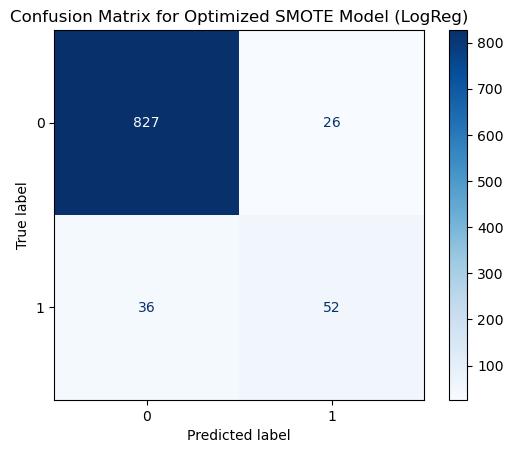

Train Acc:0.8400702987697716
Test Acc:0.8639744952178533
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       853
           1       0.67      0.59      0.63        88

    accuracy                           0.93       941
   macro avg       0.81      0.78      0.80       941
weighted avg       0.93      0.93      0.93       941



In [10]:
#Best Model
best_mod = LogisticRegression(random_state=101, C=0.1, penalty='l1', solver='saga', max_iter=1000)
best_mod.fit(X_sm, y_sm)

y_prob = best_mod.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.80).astype(int)
best_mod_train = best_mod.score(X_sm, y_sm)
best_mod_test = best_mod.score(X_test_scaled, y_test)



best_mod_conf = confusion_matrix(y_test, y_pred)
conf_plot = ConfusionMatrixDisplay(confusion_matrix=best_mod_conf)
conf_plot.plot(cmap="Blues")
plt.title("Confusion Matrix for Optimized SMOTE Model (LogReg)")
plt.savefig("../visualizations/LR_ML/op_SMOTE_matrix_LR.png")
plt.show()

print(f"Train Acc:{best_mod_train}")
print(f"Test Acc:{best_mod_test}")
print(classification_report(y_test, y_pred))

